Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


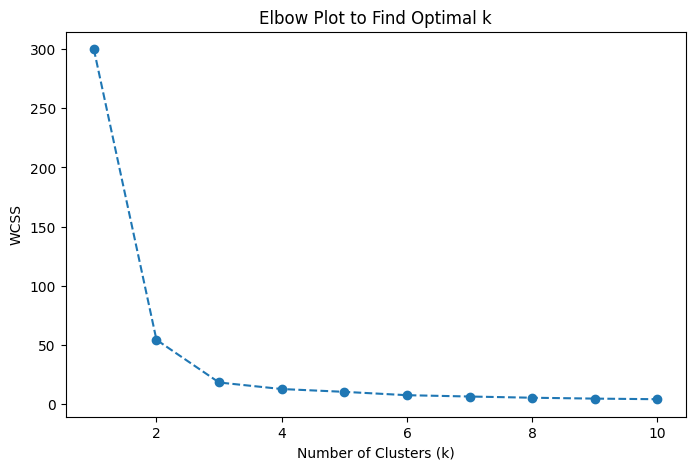

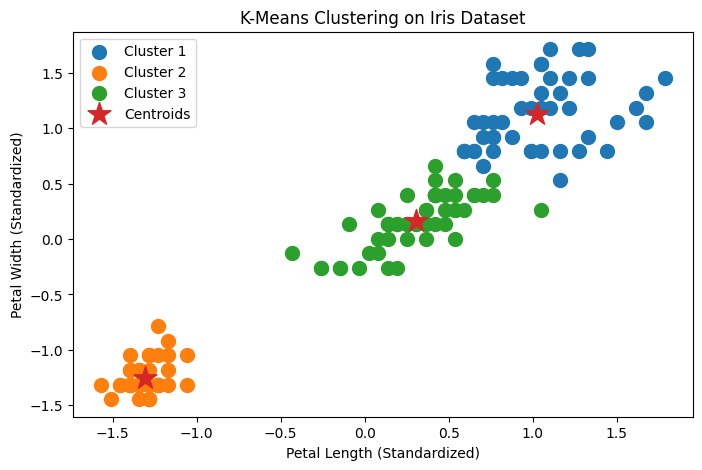

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset (fix filename if needed)
df = pd.read_csv("iris (1).csv")

# Check column names (IMPORTANT)
print(df.columns)

# Fix column names based on output above
X = df[['petal_length', 'petal_width']]   # change if needed

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot elbow graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Plot to Find Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

# KMeans with optimal k
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Plot clusters
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], s=100, label='Cluster 1')
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], s=100, label='Cluster 2')
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], s=100, label='Cluster 3')

# Centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, marker='*', label='Centroids')

plt.title('K-Means Clustering on Iris Dataset')
plt.xlabel('Petal Length (Standardized)')
plt.ylabel('Petal Width (Standardized)')
plt.legend()
plt.show()

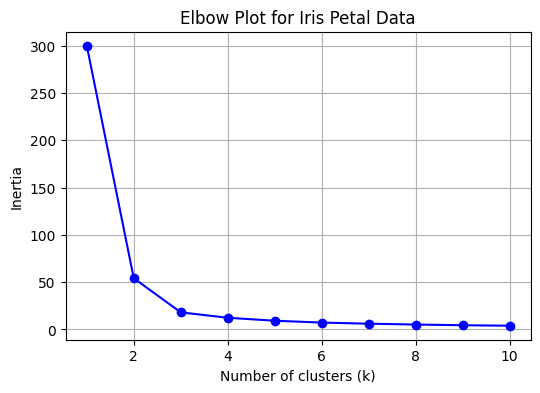

Cluster centers (petal_length, petal_width):
Cluster 0: 5.57, 2.06
Cluster 1: 1.46, 0.24
Cluster 2: 4.30, 1.32


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load data and select features
df = pd.read_csv("iris (1).csv")
X = df[['petal_length', 'petal_width']].values

# 2. Preprocessing: scaling (recommended for K‑Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Elbow method: inertia for k = 1..10
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 4. Plot elbow curve
plt.figure(figsize=(6, 4))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot for Iris Petal Data')
plt.grid(True)
plt.show()

# 5. Choose optimal k (here k=3 is the natural elbow)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# 6. Show cluster centers (in original scale)
centers_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
print("Cluster centers (petal_length, petal_width):")
for i, center in enumerate(centers_original):
    print(f"Cluster {i}: {center[0]:.2f}, {center[1]:.2f}")